# Spaceship Titanic — Improved ML Pipeline
**Key upgrades over baseline:**
- Cabin split → Deck, CabinNum, Side (3 new features)
- PassengerId → GroupSize, IsAlone (2 new features)
- TotalSpend, HasSpent, SpendLog (3 new features)
- CryoSleep domain-logic imputation (no more mean fill on spending)
- LightGBM with 5-fold stratified CV + early stopping
- OOF predictions → reliable score estimate before submitting

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

## 2. Load data

In [2]:
train = pd.read_csv("../../datasets/spaceship-titanic/train.csv")
test  = pd.read_csv("../../datasets/spaceship-titanic/test.csv")
print(f"Train: {train.shape}  |  Test: {test.shape}")
train.head()

Train: (8693, 14)  |  Test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 3. Quick EDA

In [3]:
# Missing values
missing = train.isnull().sum()
print("=== Missing values in train ===")
print(missing[missing > 0])

# Target distribution
print("\n=== Target distribution ===")
print(train['Transported'].value_counts(normalize=True).round(3))

=== Missing values in train ===
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
dtype: int64

=== Target distribution ===
Transported
True     0.504
False    0.496
Name: proportion, dtype: float64


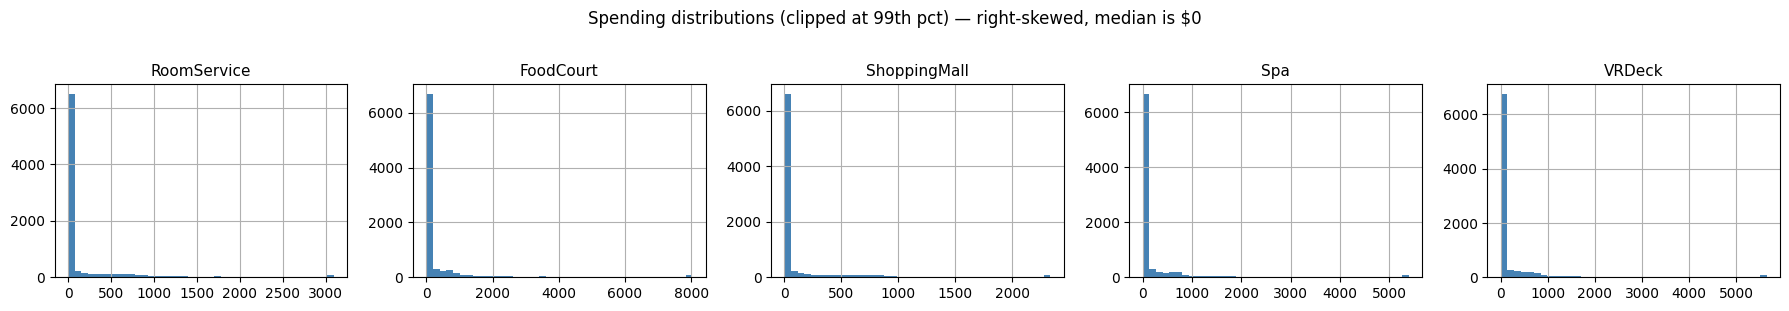

In [4]:
# Spending distribution — notice the heavy right skew (most spend $0)
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, col in zip(axes, spend_cols):
    train[col].clip(upper=train[col].quantile(0.99)).hist(
        bins=40, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
fig.suptitle('Spending distributions (clipped at 99th pct) — right-skewed, median is $0',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

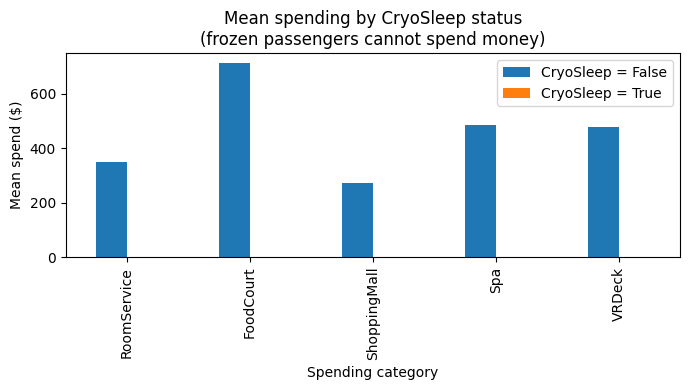

In [5]:
# CryoSleep vs spending — key domain insight used in imputation
fig, ax = plt.subplots(figsize=(7, 4))
cryo_spend = train.groupby('CryoSleep')[spend_cols].mean()
cryo_spend.T.plot(kind='bar', ax=ax)
ax.set_title('Mean spending by CryoSleep status\n(frozen passengers cannot spend money)')
ax.set_xlabel('Spending category')
ax.set_ylabel('Mean spend ($)')
ax.legend(['CryoSleep = False', 'CryoSleep = True'])
plt.tight_layout()
plt.show()

## 4. Feature engineering

Three key extractions:
1. **Cabin** `"B/0/P"` → `Deck` (B), `CabinNum` (0), `Side` (P or S)
2. **PassengerId** `"0003_02"` → `Group` ID, `GroupSize`, `IsAlone`
3. **Spending** → `TotalSpend`, `HasSpent`, `SpendLog` (log1p de-skews the tail)

In [6]:
def engineer_features(df):
    """Extract Cabin features, group features, and spending aggregates."""
    df = df.copy()

    # ── Cabin: "B/0/P" → Deck, CabinNum, Side ─────────────────────────────
    df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')

    # ── Group info from PassengerId: "0003_02" ─────────────────────────────
    df['Group']     = df['PassengerId'].str[:4]          # group id "0003"
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    df['IsAlone']   = (df['GroupSize'] == 1).astype(int)

    # ── Spending aggregates ────────────────────────────────────────────────
    spend = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpend'] = df[spend].fillna(0).sum(axis=1)
    df['HasSpent']   = (df['TotalSpend'] > 0).astype(int)
    df['SpendLog']   = np.log1p(df['TotalSpend'])        # de-skew heavy tail

    # ── Drop raw columns we've extracted from ─────────────────────────────
    df.drop(['Name', 'Cabin', 'Group'], axis=1, inplace=True)

    return df

## 5. Imputation

**Domain logic (most important step):**
- If `TotalSpend > 0` → passenger was **not** in CryoSleep (frozen people can't buy things)
- If `CryoSleep == True` → all spending **must** be 0

After applying domain logic, very few NaNs remain in spending columns.
The rest are filled with 0 (the actual median for spending is $0).

Age is filled by HomePlanet group median — smarter than a global mean.

In [7]:
def impute(df):
    """Apply domain-logic imputation then statistical fill for remaining NaNs."""
    df   = df.copy()
    spend = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # ── Domain logic ───────────────────────────────────────────────────────
    # Spending > 0 → definitely not in CryoSleep
    df.loc[df['TotalSpend'] > 0, 'CryoSleep'] = False
    # CryoSleep = True → all spending must be 0
    for col in spend:
        df.loc[df['CryoSleep'] == True, col] = 0.0

    # ── Fill remaining spending with 0 (actual median is 0) ───────────────
    df[spend] = df[spend].fillna(0)

    # ── Recompute aggregates with clean spending data ──────────────────────
    df['TotalSpend'] = df[spend].sum(axis=1)
    df['HasSpent']   = (df['TotalSpend'] > 0).astype(int)
    df['SpendLog']   = np.log1p(df['TotalSpend'])

    # ── Boolean columns ────────────────────────────────────────────────────
    df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(bool)
    df['VIP']       = df['VIP'].fillna(False).astype(bool)

    # ── Age: fill by HomePlanet group, then global median ─────────────────
    df['Age'] = df.groupby('HomePlanet')['Age'].transform(
        lambda x: x.fillna(x.median())
    )
    df['Age'].fillna(df['Age'].median(), inplace=True)

    # ── Categoricals: fill with mode ──────────────────────────────────────
    for col in ['HomePlanet', 'Destination', 'Deck', 'Side']:
        df[col].fillna(df[col].mode()[0], inplace=True)

    # ── CabinNum: fill with median ────────────────────────────────────────
    df['CabinNum'].fillna(df['CabinNum'].median(), inplace=True)

    return df

## 6. Full preprocessing pipeline

Combine train + test before encoding so dummy columns are consistent across both sets.
This avoids column-mismatch errors at submission time.

In [8]:
# Save IDs and target before merging
test_ids = test['PassengerId'].copy()
target   = train['Transported'].copy()

# Combine for consistent preprocessing
combined = pd.concat(
    [train.drop('Transported', axis=1), test],
    axis=0
).reset_index(drop=True)

# Apply pipeline
combined = engineer_features(combined)
combined = impute(combined)

# One-hot encode categoricals
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
combined = pd.get_dummies(combined, columns=cat_cols, drop_first=False)

# Convert booleans to int (LightGBM prefers numeric)
for col in ['CryoSleep', 'VIP']:
    combined[col] = combined[col].astype(int)

# Drop PassengerId (already saved)
combined.drop('PassengerId', axis=1, inplace=True)

# Split back into train / test
n_train = len(train)
X      = combined.iloc[:n_train].reset_index(drop=True)
X_test = combined.iloc[n_train:].reset_index(drop=True)
y      = target.astype(int).reset_index(drop=True)

print(f"X:      {X.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nAll features ({len(X.columns)}):")
print(list(X.columns))

X:      (8693, 30)
X_test: (4277, 30)

All features (30):
['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum', 'GroupSize', 'IsAlone', 'TotalSpend', 'HasSpent', 'SpendLog', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_P', 'Side_S']


In [9]:
# Sanity check — should be zero nulls after imputation
null_X    = X.isnull().sum().sum()
null_test = X_test.isnull().sum().sum()
print(f"Nulls in X:      {null_X}")
print(f"Nulls in X_test: {null_test}")
assert null_X == 0 and null_test == 0, "Fix nulls before training!"
print("All clear — ready to model.")

Nulls in X:      0
Nulls in X_test: 0
All clear — ready to model.


## 7. LightGBM with 5-fold stratified CV

Why this is better than your old approach:
- **StratifiedKFold** preserves class balance in each fold
- **OOF (out-of-fold) predictions** give an unbiased accuracy estimate
- **Averaging test probabilities** across 5 folds is more stable than one prediction
- **Early stopping** prevents overfitting without manual tuning of `n_estimators`
- **No StandardScaler needed** — tree models are invariant to feature scale

In [10]:
lgbm = LGBMClassifier(
    n_estimators    = 2000,      # early stopping will find the right number
    learning_rate   = 0.05,
    num_leaves      = 63,        # controls tree complexity
    min_child_samples = 20,      # prevents overfitting on small leaves
    subsample       = 0.8,       # row subsampling per tree
    colsample_bytree= 0.8,       # feature subsampling per tree
    reg_alpha       = 0.1,       # L1 regularisation
    reg_lambda      = 0.1,       # L2 regularisation
    random_state    = 16,
    verbose         = -1
)

skf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=16)
oof_preds   = np.zeros(len(X))
test_probs  = np.zeros(len(X_test))   # averaged probabilities across folds
fold_scores = []

print("Training LightGBM — 5-fold CV\n" + "-"*40)
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr,  X_val = X.iloc[train_idx],  X.iloc[val_idx]
    y_tr,  y_val = y.iloc[train_idx],  y.iloc[val_idx]

    lgbm.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            early_stopping(stopping_rounds=100, verbose=False),
            log_evaluation(period=-1)
        ]
    )

    val_preds          = lgbm.predict(X_val)
    oof_preds[val_idx] = val_preds
    test_probs        += lgbm.predict_proba(X_test)[:, 1] / 5

    fold_acc = accuracy_score(y_val, val_preds)
    fold_scores.append(fold_acc)
    print(f"Fold {fold + 1}  |  accuracy: {fold_acc:.4f}  |  "
          f"best iteration: {lgbm.best_iteration_}")

print("\n" + "="*40)
print(f"Mean CV accuracy: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"OOF  accuracy:    {accuracy_score(y, oof_preds):.4f}")

Training LightGBM — 5-fold CV
----------------------------------------


  File "c:\Users\Sharanya Nagar\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Sharanya Nagar\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Sharanya Nagar\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Sharanya Nagar\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1491, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Fold 1  |  accuracy: 0.8378  |  best iteration: 138
Fold 2  |  accuracy: 0.8056  |  best iteration: 94
Fold 3  |  accuracy: 0.8120  |  best iteration: 108
Fold 4  |  accuracy: 0.8055  |  best iteration: 134
Fold 5  |  accuracy: 0.7992  |  best iteration: 104

Mean CV accuracy: 0.8120 ± 0.0135
OOF  accuracy:    0.8120


### OOF classification report

In [11]:
print(classification_report(
    y, oof_preds,
    target_names=['Not Transported', 'Transported']
))

                 precision    recall  f1-score   support

Not Transported       0.81      0.81      0.81      4315
    Transported       0.81      0.82      0.81      4378

       accuracy                           0.81      8693
      macro avg       0.81      0.81      0.81      8693
   weighted avg       0.81      0.81      0.81      8693



## 8. Feature importance

This shows which features are actually doing the heavy lifting.
If your new features (Deck, Side, TotalSpend, GroupSize) are near the top — great.
If they're at the bottom, re-examine the engineering.

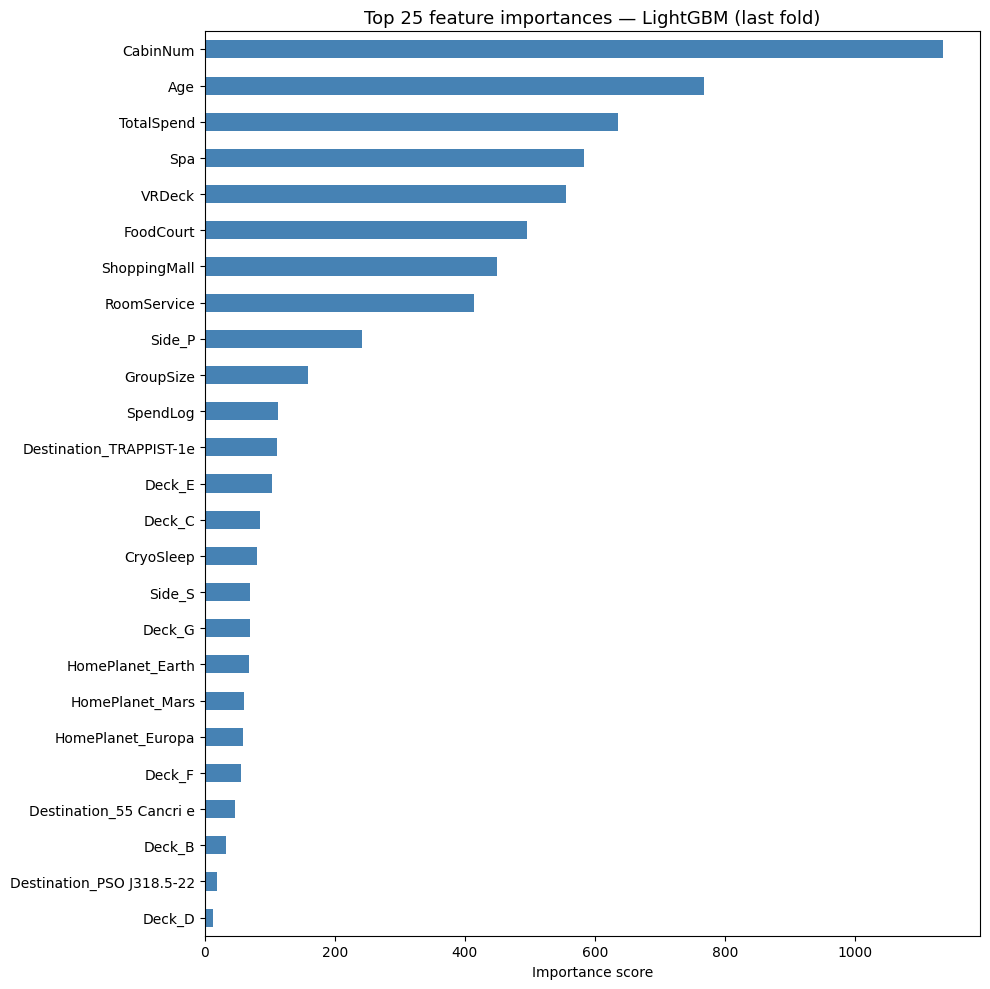

In [12]:
importance = pd.Series(
    lgbm.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
importance.tail(25).plot(
    kind='barh', ax=ax,
    color='steelblue', edgecolor='none'
)
ax.set_title('Top 25 feature importances — LightGBM (last fold)', fontsize=13)
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

## 9. (Optional) Stacking ensemble

Uncomment to try stacking LightGBM + XGBoost with a Logistic Regression meta-learner.
Typically adds +0.3–0.8% accuracy at the cost of ~5× training time.

In [ ]:
# from sklearn.ensemble import StackingClassifier

# stack = StackingClassifier(
#     estimators=[
#         ('lgbm', LGBMClassifier(
#             n_estimators=500, learning_rate=0.05, num_leaves=63,
#             subsample=0.8, colsample_bytree=0.8, random_state=16, verbose=-1)),
#         ('xgb', XGBClassifier(
#             n_estimators=500, learning_rate=0.05, max_depth=6,
#             subsample=0.8, colsample_bytree=0.8,
#             eval_metric='logloss', random_state=16, verbosity=0)),
#     ],
#     final_estimator=LogisticRegression(max_iter=1000),
#     cv=5, n_jobs=-1, passthrough=False
# )

# stack_scores = cross_val_score(stack, X, y, cv=skf, scoring='accuracy')
# print(f"Stack CV: {stack_scores.mean():.4f} ± {stack_scores.std():.4f}")

print("Uncomment the block above to run the stacking ensemble.")

## 10. Generate Kaggle submission

We use the **averaged test probabilities** from all 5 folds — not a single model fit on 80% of data.
This gives a more robust prediction.

In [ ]:
# Convert averaged probabilities → boolean labels
final_preds = (test_probs > 0.5)

submission = pd.DataFrame({
    'PassengerId': test_ids.values,
    'Transported': final_preds
})

submission.to_csv("submission.csv", index=False)

print("submission.csv saved!")
print(f"Transported: {final_preds.sum()} / {len(final_preds)} "
      f"({final_preds.mean():.1%} of test set)")
submission.head(10)